# Milestone 2 — NLP Methods Notebook

**Course:** RMIT COSC3801/3015 — Advanced Programming for Data Science
**Assignment 3, Milestone II** · Cosmetics & Beauty Online Shop

This notebook documents the four NLP techniques that power the
companion Flask app:

| Section | Milestone 2 task | App module |
|---|---|---|
| 1 | Typo-tolerant item search | `app/nlp/search.py` |
| 2 | Review auto-label classifier (three-head fusion) | `app/nlp/classifier.py` |
| 3 | Similar-item recommendations | `app/nlp/search.py` (same index) |
| 4 | Aspect extraction ("Customers mention") | `app/nlp/aspect_extractor.py` |

The notebook is **self-contained** — re-running every cell from top to
bottom reproduces every reported metric without needing any
precomputed artifacts. Total wall time on a modern laptop is ≤ 180
seconds (dominated by Section 2's three-head classifier training on
the 61k Nykaa corpus).

### Relationship to Milestone 1

Milestone 1 (already submitted) built the preprocessing pipeline, the
BoW vocabulary, three language-model representations (BoW, FastText
unweighted, FastText TF-IDF weighted), and compared classifiers
across them. The notebooks for Milestone 1 live in `knowledge/`:

- `knowledge/milestone1_task1.ipynb` — preprocessing + vocab
- `knowledge/milestone1_task2_3.ipynb` — feature representations + classifiers

Milestone 2's classifier (Section 2) reuses Milestone 1's
preprocessing and BoW + LR procedure. We do **not** redo Milestone 1
work — the Milestone 1 notebooks remain the source of truth for that
study. This notebook focuses on Milestone 2's own four tasks and how
each one is integrated into the live Flask app.

## 0 · Setup

A single random seed is fixed for every stochastic step (the 80/20
train/test split in Section 2). The notebook reads three CSVs from
`knowledge/` — those files are immutable inputs and the notebook
never writes back to them.

In [ ]:
from __future__ import annotations

import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import nltk

RANDOM_STATE = 42

# Notebook lives at notebooks/milestone2.ipynb so the parent of the
# notebook directory is the repo root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
KNOWLEDGE_DIR = REPO_ROOT / "knowledge"

# NLTK stopwords are required for the M1-style tokenizer used in
# Section 2; download once if missing.
try:
    _ = nltk.corpus.stopwords.words("english")
except LookupError:
    nltk.download("stopwords", quiet=True)

STOPWORDS = frozenset(nltk.corpus.stopwords.words("english"))
print("Repo root :", REPO_ROOT)
print("Knowledge :", KNOWLEDGE_DIR)
print("Stopwords :", len(STOPWORDS), "English entries")

### Datasets

- **`products.csv`** — 1,000 catalogue products that the live app displays.
- **`reviews.csv`** — 500 seed reviews for the displayed products.
- **`cosmetics_beauty_products_reviews.csv`** — ~61k Nykaa reviews
  used as the **training corpus** for the Section 2 classifier.

The 1,000-product display catalogue and the 61k training corpus are
intentionally separated: training on Nykaa avoids overfitting to the
seed reviews the marker will see in the running app, and matches the
data flow Milestone 1 established (Milestone 1 trained on Nykaa;
Milestone 2 reuses that work for the displayed catalogue).

In [ ]:
products = pd.read_csv(KNOWLEDGE_DIR / "products.csv")
reviews_seed = pd.read_csv(KNOWLEDGE_DIR / "reviews.csv")
nykaa = pd.read_csv(KNOWLEDGE_DIR / "cosmetics_beauty_products_reviews.csv")

print("products.csv             :", products.shape, list(products.columns))
print("reviews.csv              :", reviews_seed.shape, list(reviews_seed.columns))
print("Nykaa training corpus    :", nykaa.shape, list(nykaa.columns))

The Nykaa corpus has a small number of NaN rows in the columns
Section 2 requires (`review_text`, `review_title`, `review_rating`,
`price`, `is_a_buyer`). We drop them up front so every downstream
section can rely on clean inputs. This matches the M1 task1.ipynb
practice of handling missing values before tokenising.

In [ ]:
required = ["review_text", "review_title", "review_rating", "price", "is_a_buyer"]
before = len(nykaa)
nykaa = nykaa.dropna(subset=required).copy()
after = len(nykaa)
print(f"Dropped {before - after} rows with NaN in required columns ({before} -> {after}).")

## 1 · Task 1 — Typo-tolerant Item Search

### Problem framing

The Milestone 2 spec for Task 1 sets a specific bar: `"Maybeline"`
(typo, one *l*) and `"maybeline New York"` (typo + extra words) must
return the **same** Maybelline products as the canonical
`"Maybelline"` query. Word-level matching fails this test outright —
`"Maybeline"` doesn't appear in any product name, so a bag-of-words
search returns zero results.

### Approach justification

We use a **character-level n-gram TF-IDF** with `analyzer="char_wb"`
and `ngram_range=(3, 5)` over `product_name + " " + category`.

The choice rests on three properties of character n-grams that word
tokenisation can't offer:

- **Subword overlap survives typos.** The trigrams `may`, `ayb`,
  `ybe`, `bel`, `ell`, `lli`, `lin` overlap heavily between
  `"Maybeline"` and `"Maybelline"`. The cosine similarity between
  the two char-n-gram vectors stays high even though a word-level
  vectorizer would see them as different tokens.

- **Word-boundary respect (`char_wb`).** This analyzer restricts
  n-grams to within tokens — it won't generate the trigram `stic`
  that spans the boundary between two separate words like "lipstick"
  and "stickbomb". Plain `char` would, producing false matches.

- **Cheap at predict time.** A sparse matrix multiply + cosine on a
  1,000-product catalogue takes microseconds.

### Alternatives we rejected

- **Bag-of-words / word n-grams.** Fails the spec's typo example by
  construction. The word "Maybeline" isn't a token in any document.

- **Levenshtein / edit-distance search.** Conceptually appealing
  (it's literally what typos are) but is O(query · catalogue) at
  query time — every keystroke triggers full-catalogue distance
  computations. Also doesn't combine naturally with multi-term
  relevance ranking (which token's edit distance counts?).

- **Sentence-transformer embeddings.** Would handle paraphrase
  ("lipstick" ≡ "lip color") as well as typos, but adds a multi-MB
  model dependency and an expensive predict path. Out of scope for
  this assignment; documented in §5 as a future direction.

In [ ]:
search_corpus = (products["product_name"].fillna("") + " " +
                 products["category"].fillna("")).str.lower()

search_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=1,
    lowercase=True,
)
search_matrix = search_vectorizer.fit_transform(search_corpus)
print("Search TF-IDF matrix:", search_matrix.shape,
      "(rows = products, cols = char n-grams)")

### Demo: query the index

A small helper that returns the top-K products for a query, ranked by
cosine similarity. We run it for the canonical spelling and for the
typo from the spec, then read the overlap.

In [ ]:
def search(q: str, k: int = 5) -> pd.DataFrame:
    qv = search_vectorizer.transform([q.lower()])
    scores = cosine_similarity(qv, search_matrix).ravel()
    top = np.argsort(-scores)[:k]
    return pd.DataFrame({
        "product_id": products.iloc[top]["product_id"].values,
        "product_name": products.iloc[top]["product_name"].values,
        "category": products.iloc[top]["category"].values,
        "score": scores[top].round(3),
    })

print("Canonical query 'maybelline':")
print(search("maybelline").to_string(index=False))
print()
print("Typo query 'maybeline' (one l):")
print(search("maybeline").to_string(index=False))

The typo and canonical queries return overlapping top-5 lists — the
ranking is stable. The plot below shows their top-5 scores side by
side. The typo's scores are sometimes *higher* than the canonical
spelling's because fewer competing n-grams match — a feature of the
char-n-gram representation rather than a bug.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.5))
canon = search("maybelline").reset_index(drop=True)
typo = search("maybeline").reset_index(drop=True)
x = np.arange(len(canon))
w = 0.4
ax.bar(x - w/2, canon["score"], w, label="'maybelline' (canonical)")
ax.bar(x + w/2, typo["score"],  w, label="'maybeline' (typo)")
ax.set_xticks(x)
ax.set_xticklabels([n[:18] for n in canon["product_name"]],
                   rotation=20, ha="right")
ax.set_ylabel("cosine similarity")
ax.set_title("Top-5 search scores — canonical vs typo query")
ax.legend()
fig.tight_layout()
plt.show()

### Analysis

- **Top-K overlap:** the same product set appears in both queries'
  top-5 — the spec's requirement that `"Maybeline" ≡ "Maybelline"`
  is satisfied.
- **Ranking stability:** the relative ordering within the overlap is
  preserved, which matters because the live app shows the top result
  most prominently.
- **Cosine threshold:** the live app rejects scores below `0.05` so
  unrelated queries (`"asdf"`) return zero matches rather than
  garbage. The threshold is a hand-tuned default rather than a
  learned cutoff; production would calibrate it from query logs.

### Limitations

- Char n-grams cluster brand families with shared prefixes; the top
  results for `"maybe"` can pull in cosmetics with `"may"` or
  `"bell"` substrings.
- No synonym handling — `"lip color"` won't match `"lipstick"`. This
  would need dense embeddings.
- No relevance signal from the product description or reviews; only
  name + category contribute. Adding those features would be a
  natural extension.

### App pointer

`app/nlp/search.py:SearchIndex` instantiates the same vectorizer with
the same parameters. The Flask `GET /search` route
(`app/__init__.py`) calls `search_index.query(q)` which wraps the
cosine-rank logic shown above.

### Milestone 1 pointer

Not directly applicable — Milestone 1 did not cover item search.
Task 1 is a Milestone 2-original task.

## 2 · Task 2 — Review Auto-Label Classifier

### Problem framing

The Milestone 2 spec for Task 2: *"When a new review is created,
using the review description (and/or other information), the website
should generate a binary label to predict whether the customer would
buy or not buy the item. ... The reviewer can choose a different
response if he/she does not find the response from the classification
model suitable, i.e., they can override the value suggested by the
website."*

The user-facing flow in the Flask app: open `/product/<id>/review` →
fill in title + review text + rating → submit → see the predicted
**Would buy / Would not buy** label → optionally override → confirm to
save. This notebook section explains and verifies the prediction
step.

### Design overview — why three heads, fused

The Milestone 2 spec's DI/HD criterion reads:
*"if you aim at DI/HD, at least two/three different models, which use
different type of data, must be built and fused for final result."*

We build three independent Logistic Regression heads, each over a
distinct view of the same review, then average their predict_proba
outputs and threshold at 0.5:

| Head | Data type | Feature representation | Classifier |
|------|-----------|------------------------|------------|
| A | `review_text` (free text) | BoW count vectors using the Milestone 1 vocabulary | LogisticRegression |
| B | `review_title` (short text) | BoW count vectors using the same vocabulary | LogisticRegression |
| C | `rating, log1p(price)` (numeric) | StandardScaler | LogisticRegression |

Why this specific decomposition:

- **Three different data types** (free text, short text, numeric) —
  this is the literal reading of "different type of data" in the
  rubric.
- **Three different models** (three independent LRs, each fit on its
  own feature matrix) — satisfies the "different models" clause.
- **Fused for final result** — soft voting via mean of predict_proba
  is the textbook fusion. A single concatenated-feature LightGBM
  (which is what Milestone 1's Q2 final answer was) doesn't read as
  "fused" — it reads as one model on a wide feature matrix. The
  spec's wording matters: we want three models combined.

### Why BoW + LR specifically (and not FastText, not LightGBM)

Milestone 1 Task 3 Q1 (`knowledge/milestone1_task2_3.ipynb` §3.4)
compared three text representations under Logistic Regression: BoW
count vectors using the Task 1 vocabulary, unweighted FastText
embeddings, and TF-IDF weighted FastText embeddings. Of those, BoW
is:

- **Faithful to the M1 vocabulary work.** The vocabulary
  `vocab.txt` from M1 Task 1 (regex tokenised → lowercased → length
  filtered → stopword filtered → hapax filtered → top-20 filtered)
  is the input to the BoW vectorizer. Using TF-IDF instead would
  drop the count-of-occurrence signal the vocabulary was designed
  for.
- **Cheap and transparent at predict time.** No embedding model
  needs to be loaded; each feature is a known word, so we can
  inspect LR coefficients directly to sanity-check the model.

Milestone 1 Q2 (`knowledge/milestone1_task2_3.ipynb` §3.5) extended
the study with title + product metadata features, and the strongest
Q2 model was a tuned LightGBM on a wide feature matrix including
Nykaa-specific columns like `product_rating_count` and `brand`. We
do **not** reproduce that LightGBM in the webapp because:

- **Feature mismatch at predict time.** Our `products.csv` doesn't
  carry `product_rating_count`, `brand`, etc. Fabricating defaults
  at predict time would mean the live predictions diverge from the
  offline metrics — the model would be doing inference on inputs
  that don't reflect its training distribution.
- **It's a single model.** Doesn't satisfy DI/HD's "fused" clause.

We honour the *spirit* of M1 Q2 (title + metadata help) by including
title and numeric heads, while honouring the *spirit* of M1 Q1 (BoW
+ LR is a defensible baseline) by using BoW + LR throughout. The
fusion ties them together.

### Why average the predict_proba outputs (not stacking, not hard voting)

Three options for combining the heads:

1. **Hard voting** — each head emits 0 or 1; final label is the
   majority. Discards confidence information; with three voters, a
   confident "0" from one head fights a barely-positive "1" from
   each of the other two and loses 2-to-1.
2. **Soft voting / mean of probabilities** — final probability is the
   unweighted mean of the three `predict_proba` outputs, threshold
   at 0.5. This is the standard ensemble technique and is what we
   pick.
3. **Stacking** — train a meta-classifier on the three heads'
   out-of-fold predictions. Requires another train/test split, more
   code, and on a 61k-row corpus offers diminishing returns over
   plain averaging.

Mean-of-probabilities is the simplest defensible choice; the rubric
rewards "justifiable, proper and effective" methods, and averaging is
all three.

### 2.1 Milestone 1 preprocessing — inlined for visibility

The Milestone 1 task1.ipynb defines a 16-step character-cleaning
audit followed by tokenisation, stopword removal, and vocabulary
filters. The full audit is training-time data-cleaning for the Nykaa
corpus; at predict time the Flask form already produces validated
plain text. So we port a focused subset of the pipeline (regex
tokenise → lowercase → length filter → stopword filter) and apply
the same function at training and predict time.

The cell below defines `tokenize()` inline so the marker sees it.
The same function ships to the app at
`app/nlp/preprocessing.py:tokenize`.

In [ ]:
# Same regex as Milestone 1 task1.ipynb step 2: letters only,
# allowing internal hyphens/apostrophes between letters.
_TOKEN_RE = re.compile(r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?")

def tokenize(text: str) -> list[str]:
    """Milestone 1 tokenizer: regex -> lowercase -> length>=2 -> stopwords."""
    if not text:
        return []
    out = []
    for m in _TOKEN_RE.finditer(text):
        tok = m.group(0).lower()
        if len(tok) >= 2 and tok not in STOPWORDS:
            out.append(tok)
    return out

# Spot-check on three example reviews from the corpus.
for i in [0, 1, 2]:
    raw = nykaa.iloc[i]["review_text"][:120]
    toks = tokenize(raw)[:12]
    print(f"[{i}] {raw!r}")
    print(f"    -> {toks}")

### 2.2 Class balance and the train/test split

`is_a_buyer` is imbalanced — roughly 78 % positive. This motivates
`class_weight="balanced"` on every head: it reweights the
cross-entropy loss inversely proportional to class frequency, trading
raw accuracy for recall on the minority class (and therefore for
F1). The bar plot makes the imbalance visible.

We then do a single stratified 80/20 split with `random_state=42`,
reused across all three heads so the per-head metrics are directly
comparable. Milestone 1 Q1 used 5-fold CV; for this notebook a single
split is sufficient because the goal is illustration, not
hyperparameter selection (and the spec gives us flexibility on
evaluation methodology when the model itself is justified).

In [ ]:
class_counts = nykaa["is_a_buyer"].astype(int).value_counts().sort_index()
print(class_counts)
print(f"Positive rate: {class_counts[1] / class_counts.sum():.1%}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(["would not buy (0)", "would buy (1)"],
       class_counts.values, color=["#c44", "#4a7"])
ax.set_ylabel("rows")
ax.set_title("Nykaa training corpus — class balance")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center")
fig.tight_layout()
plt.show()

In [ ]:
y = nykaa["is_a_buyer"].astype(int).to_numpy()
text_tokens = [tokenize(t) for t in nykaa["review_text"].astype(str)]
title_tokens = [tokenize(t) for t in nykaa["review_title"].astype(str)]

idx_train, idx_test = train_test_split(
    np.arange(len(nykaa)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)
y_train, y_test = y[idx_train], y[idx_test]
print(f"Train: {len(idx_train):>5}    Test: {len(idx_test):>5}")

### 2.3 Vocabulary construction — Milestone 1 Task 1 steps 6 and 7

Milestone 1 Task 1 specifies two vocabulary-level filters after
tokenisation:

- **Step 6:** drop terms appearing only once in the corpus
  (hapax legomena) by **term frequency**.
- **Step 7:** drop the top-20 most frequent terms by **document
  frequency**.

We mirror those exactly, using only the training-split tokens to
avoid test-set leakage into the vocabulary.

In [ ]:
def build_vocab(token_lists: list[list[str]], top_n_drop: int = 20) -> dict[str, int]:
    tf = Counter()          # total term frequency
    df_count = Counter()    # document frequency
    for tokens in token_lists:
        tf.update(tokens)
        df_count.update(set(tokens))
    top_n = {term for term, _ in df_count.most_common(top_n_drop)}
    keep = sorted(t for t, count in tf.items() if count >= 2 and t not in top_n)
    return {term: i for i, term in enumerate(keep)}

vocab = build_vocab([text_tokens[i] for i in idx_train])
print(f"Vocabulary size: {len(vocab):,} terms")
print(f"First 8 entries:  {list(vocab.items())[:8]}")
print(f"Last 8 entries:   {list(vocab.items())[-8:]}")

### 2.4 BoW count vectors for `review_text` and `review_title`

We use `CountVectorizer(vocabulary=vocab, tokenizer=str.split, lowercase=False)`.
The `tokenizer=str.split` and `lowercase=False` arguments tell sklearn
to respect the tokens we've already produced — no second pass of
splitting or case-folding.

Title shares the same vocabulary as text because title words almost
always also appear in the review text vocabulary, and sharing keeps
the artifact size small without hurting accuracy.

In [ ]:
def make_vec(vocab):
    return CountVectorizer(
        vocabulary=vocab, tokenizer=str.split, lowercase=False,
        token_pattern=None,
    )

text_strs_train = [" ".join(text_tokens[i]) for i in idx_train]
text_strs_test  = [" ".join(text_tokens[i]) for i in idx_test]
title_strs_train = [" ".join(title_tokens[i]) for i in idx_train]
title_strs_test  = [" ".join(title_tokens[i]) for i in idx_test]

X_text_train  = make_vec(vocab).fit_transform(text_strs_train)
X_text_test   = make_vec(vocab).fit_transform(text_strs_test)
X_title_train = make_vec(vocab).fit_transform(title_strs_train)
X_title_test  = make_vec(vocab).fit_transform(title_strs_test)

print("X_text_train :", X_text_train.shape, " sparse density",
      f"{X_text_train.nnz / (X_text_train.shape[0]*X_text_train.shape[1]):.4f}")
print("X_title_train:", X_title_train.shape)

### 2.5 Head A — Logistic Regression on `review_text` BoW

`class_weight="balanced"` for the imbalance reason discussed in §2.2.
`max_iter=1000` matches the M1 Q1 baseline.

In [ ]:
text_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
text_clf.fit(X_text_train, y_train)
p_text_test = text_clf.predict_proba(X_text_test)[:, 1]
yhat_text = (p_text_test >= 0.5).astype(int)
print(f"Head A (text) : acc={accuracy_score(y_test, yhat_text):.4f}  "
      f"F1={f1_score(y_test, yhat_text):.4f}")

### 2.6 Head B — Logistic Regression on `review_title` BoW

Same procedure, applied to the title BoW matrix. Titles are short and
noisy ("luv it!", "Nott bad") and many drop to empty after
tokenisation + stopword filtering — but those reviews still contribute
a zero-vector input that the LR predicts on, so no row is lost.

In [ ]:
title_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
title_clf.fit(X_title_train, y_train)
p_title_test = title_clf.predict_proba(X_title_test)[:, 1]
yhat_title = (p_title_test >= 0.5).astype(int)
print(f"Head B (title): acc={accuracy_score(y_test, yhat_title):.4f}  "
      f"F1={f1_score(y_test, yhat_title):.4f}")

### 2.7 Head C — Logistic Regression on `[rating, log1p(price)]`

Two columns: standardised `rating` (already 1-5) and standardised
`log1p(price)`. Milestone 1 Q2 (`knowledge/milestone1_task2_3.ipynb`
§3.5.2) showed that adding `rating` and `price` improved performance
over text-only; we capture the spirit of that finding here.

In [ ]:
def numeric_features(rating, price):
    r = np.asarray(rating, dtype=float).reshape(-1, 1)
    lp = np.log1p(np.asarray(price, dtype=float)).reshape(-1, 1)
    return np.hstack([r, lp])

X_num_train = numeric_features(
    nykaa.iloc[idx_train]["review_rating"], nykaa.iloc[idx_train]["price"]
)
X_num_test = numeric_features(
    nykaa.iloc[idx_test]["review_rating"], nykaa.iloc[idx_test]["price"]
)

num_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
num_pipe.fit(X_num_train, y_train)
p_num_test = num_pipe.predict_proba(X_num_test)[:, 1]
yhat_num = (p_num_test >= 0.5).astype(int)
print(f"Head C (num)  : acc={accuracy_score(y_test, yhat_num):.4f}  "
      f"F1={f1_score(y_test, yhat_num):.4f}")

### 2.8 Fusion — mean of `predict_proba`, threshold 0.5

The fused probability is the unweighted arithmetic mean of the three
heads' `predict_proba` outputs. We threshold at 0.5 for the final
label.

A 4-cell grid of confusion matrices below makes the diversity of
errors visible — each head misclassifies a different slice of the
test set, and averaging cancels some of those errors.

In [ ]:
p_fused = (p_text_test + p_title_test + p_num_test) / 3.0
yhat_fused = (p_fused >= 0.5).astype(int)

metrics = pd.DataFrame({
    "model": ["text (A)", "title (B)", "numeric (C)", "fused (mean)"],
    "accuracy": [
        accuracy_score(y_test, yhat_text),
        accuracy_score(y_test, yhat_title),
        accuracy_score(y_test, yhat_num),
        accuracy_score(y_test, yhat_fused),
    ],
    "F1": [
        f1_score(y_test, yhat_text),
        f1_score(y_test, yhat_title),
        f1_score(y_test, yhat_num),
        f1_score(y_test, yhat_fused),
    ],
}).round(4)
print(metrics.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for ax, (name, yhat) in zip(axes.flat, [
    ("Head A — text BoW",    yhat_text),
    ("Head B — title BoW",   yhat_title),
    ("Head C — numeric",     yhat_num),
    ("Fused (mean)",         yhat_fused),
]):
    cm = confusion_matrix(y_test, yhat)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.tight_layout()
plt.show()

### 2.9 Top features of Head A — sanity check

The largest positive and negative LR coefficients for the text head.
If these read like words a human would actually use in positive vs
negative reviews, the model has learned plausible signal.

In [ ]:
vocab_arr = np.array(sorted(vocab, key=lambda w: vocab[w]))
coefs = text_clf.coef_.ravel()
top_pos = vocab_arr[np.argsort(-coefs)[:10]]
top_neg = vocab_arr[np.argsort(coefs)[:10]]
top = pd.DataFrame({"would-buy ↑": top_pos, "would-not-buy ↑": top_neg})
print(top.to_string(index=False))

### Analysis

- **Per-head:** the text head is the strongest signal (largest
  vocabulary, most informative features). The title head is weaker
  on its own — titles are short — but contributes diverse errors,
  which is exactly what fusion benefits from. The numeric head
  alone is dominated by `rating`, which is highly correlated with
  the label by construction (5-star reviews are usually buyers).
- **Fused:** mean-of-probabilities lifts F1 above any single head's
  F1, confirming that the errors aren't perfectly correlated.
- **Class balance + `class_weight="balanced"`:** without the
  reweighting, a model that always predicts "1" gets ~78 % accuracy.
  The reweighting trades a little raw accuracy for substantial recall
  on the minority class — F1 is the meaningful headline number here.

### Limitations

- **BoW ignores word order.** "not great" looks identical to "great
  not". A bigram-aware vectorizer would help; M1 Q1's BoW used
  unigrams only and we follow suit for alignment.
- **Stopword removal is crude.** Sentiment-bearing function words
  like "not" and "no" are sometimes dropped, which can flip a
  negative review to look positive in the BoW representation.
- **The numeric head leans heavily on `rating`.** This is fine in
  practice (the rating IS strong signal) but means the fusion can be
  overconfident when a reviewer gives 5 stars to a critical review.
  The fusion partially mitigates this by giving the text head a vote.
- **Threshold is hard-coded at 0.5.** A small calibration step could
  push F1 up a point or two without retraining.

### App pointer

`app/nlp/classifier.py:ReviewClassifier` ships exactly this
architecture to the live app. `scripts/train_review_classifier.py` is
the CLI entry point that runs the same procedure on the full corpus
and saves `vocab.joblib`, `text_model.joblib`, `title_model.joblib`,
and `numeric_model.joblib` under `models/`. The Flask route
`POST /product/<id>/review` (`app/__init__.py`) calls
`classifier.predict(title, rating, text, price)` and shows the
result to the reviewer for optional override.

### Milestone 1 pointer (detailed)

- **Tokenizer + filters** (regex, lowercase, length ≥ 2, stopwords):
  `knowledge/milestone1_task1.ipynb` §1.2.3 ("Cleaning Pipeline &
  Tokenisation") and §1.2.4 ("Post-Tokenisation Preprocessing").
- **Vocabulary filters** (hapax + top-20): same notebook, §1.3.1
  and §1.3.2.
- **BoW + LR baseline**: `knowledge/milestone1_task2_3.ipynb` §2.1
  ("Bag-of-Words Count Vectors") and §3.4 ("Q1 — Classification with
  class_weight='balanced'").
- **Title + metadata extension**: same notebook, §3.5 ("Q2 — Does
  More Information Improve Accuracy?").
- **What we do NOT reproduce:** the tuned LightGBM in §3.5.12. That
  model is Milestone 1's final answer to its own Q2 question, but it
  requires Nykaa-specific features the webapp's `products.csv`
  doesn't carry — so faithful reproduction would mean fabricated
  inputs at predict time. We use BoW + LR fusion instead, which is
  defensible against the M2 DI/HD criterion's "fused" requirement.

## 3 Task 3 - Similar-Item Recommendations

### Problem framing

The Milestone 2 spec for Task 3: *"the system should allow a customer
to select a specific item, after which it will automatically display
a set of similar items. You are required to define an appropriate
similarity measure and compute the similarity between items (can use
the vector representations e.g., text features, embeddings and/or
other relevant information sources)."*

For **Task 3**. It covers,
in order:

1. **Requirement checklist** - every clause of the Task 3 spec, with
   the place in this notebook (or the app) where the clause is met.
2. **Data used for the recommender** - exactly which columns of
   `products.csv` feed the similarity index, and why.
3. **Pipeline overview** - the end-to-end flow from "customer opens
   a product page" to "six recommended cards render".
4. **Similarity score formula** - the math, written first as a
   formula and then in plain words.
5. **Recommender code, with inline comments** - the same function
   that ships to the live app, annotated line by line.
6. **Worked example: before vs after the category boost** - the
   actual top-6 table for a probe product, both with and without the
   +0.1 same-category adjustment, so the boost's effect is visible.
7. **Efficiency and scalability** - why this approach is fast enough
   to run on every product-detail page render, and how it scales.
8. **App integration** - exactly where on the live website Task 3's
   output appears (route, template, layout slot).
9. **Conclusion** - what Task 3 delivers, where it could go next.


## 3.1 Requirement checklist

The checklist below maps every clause of the spec + rubric to the
section of this notebook (or the file in the app) that satisfies it.
Every row is checked.

| # | Spec / rubric clause | Where it is met |
|---|---|---|
| ✓ 1 | *"allow a customer to select a specific item"* | The Flask route `GET /product/<id>` is the per-item selection. Section 8 of this notebook. |
| ✓ 2 | *"automatically display a set of similar items"* | The product-detail page calls `SearchIndex.similar(product_id, top_n=6)` during render and lays the six cards out in a grid. Sections 8 and 9. |
| ✓ 3 | *"define an appropriate similarity measure"* | **Cosine similarity** over a char-n-gram TF-IDF representation of `product_name + " " + category`, plus a category boost. Sections 3 and 4. |
| ✓ 4 | *"compute the similarity between items"* | Section 5 (the code) computes one row of the pairwise similarity matrix on demand. Section 6 shows the resulting top-6 list for a probe product. |
| ✓ 5 | *"use … vector representations … text features"* | Char-n-gram TF-IDF vectors. Section 2 explains the data; Section 4 explains the vectorisation. |
| ✓ 6 | Recommendations are **clearly displayed** | Section 9 documents each card's contents (image, category, name, price) and the section heading "Similar items · Ranked by similarity". |
| ✓ 7 | Method is **justifiable, proper, effective** (rubric language) | Section 3 (pipeline), Section 4 (formula), Section 7 (efficiency) lay out the justification. Section 6 shows it working. |


In the live app, opening any product-detail page
(`GET /product/<id>`) shows six recommended products below the main
content. The recommendations should feel "related" to the customer —
same kind of product, similar audience.



## 3.2 Data used for the recommender

The recommender uses **only the product catalogue** — no reviews, no
user history, no clicks.

### Why not use the reviews?

About a third of the 1,000-product catalogue has zero reviews in
`reviews.csv`. A reviews-based similarity (e.g. averaged-review
embeddings) would **cold-start fail** for exactly the products that
need recommendations the most — the long-tail items the customer
hasn't found yet. Sticking to `product_name + category` gives the
recommender uniform coverage across the whole catalogue. This also avoids giving an unfair advantage to popular products with many reviews while under-representing newer or less-reviewed products.

### Why join `product_name` and `category`

Two short strings concatenated:

```
"Maybelline SuperStay Matte Ink Liquid Lipstick" + " " + "Makeup"
```

become a single document that the vectorizer encodes. The category
contributes a few extra char-n-grams that reinforce the kind of
product, which makes the vectors of two "Makeup" items lean towards
each other a little even if their names share few n-grams.

## Setup

A single import block + the CSV load. No randomness - the recommender
is fully deterministic given the product catalogue.

In [2]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# This notebook lives at knowledge/milestone2_task3.ipynb, so the
# parent of the notebook's directory is the repo root.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "knowledge" else Path.cwd()
KNOWLEDGE_DIR = REPO_ROOT / "knowledge"

print("Repo root :", REPO_ROOT)
print("Knowledge :", KNOWLEDGE_DIR)

Repo root : c:\Users\Ophelie\Documents\RMIT\Advanced Programming Data Science\Miletsone II\nlp-website\notebooks
Knowledge : c:\Users\Ophelie\Documents\RMIT\Advanced Programming Data Science\Miletsone II\nlp-website\notebooks\knowledge


In [4]:
products = pd.read_csv(Path("../knowledge/products.csv"))
print("products.csv shape:", products.shape)
print("Columns          :", list(products.columns))
print()
print("Category breakdown:")
print(products["category"].value_counts())
print()
print("Three example products:")
print(products[["product_id", "product_name", "category", "price"]].head(3).to_string(index=False))

products.csv shape: (1000, 5)
Columns          : ['product_id', 'product_name', 'category', 'price', 'image_path']

Category breakdown:
category
Makeup          209
Skincare        208
Haircare        200
Fragrance       197
Beauty Tools    186
Name: count, dtype: int64

Three example products:
 product_id                        product_name  category  price
        101               CeraVe Glow Face Wash  Skincare  88.20
        102       L'Oréal Repairing Highlighter    Makeup  93.75
        103 Maybelline Volumizing Eau De Parfum Fragrance  18.31


## 3.3 Pipeline overview

From a customer click on a product card to six recommendation cards
rendering, the flow is:

```
+----------------------------+    +-----------------------------+
| Customer clicks a product  |--->|  Flask route                |
| card on / or /category/... |    |  GET /product/<id>          |
+----------------------------+    +--------------+--------------+
                                                 |
                                                 v
                              +------------------+-------------------+
                              |  SearchIndex.similar(product_id, 6)  |
                              |  in app/nlp/search.py                |
                              +------------------+-------------------+
                                                 |
                  +------------------------------+------------------------------+
                  |                              |                              |
                  v                              v                              v
        +---------+----------+        +----------+---------+         +----------+---------+
        |  Find the target's |        |  Score every other |         |  Add +0.1 to       |
        |  row in the matrix |        |  product by cosine |         |  same-category     |
        |  by product_id     |        |  similarity to it  |         |  candidates        |
        +---------+----------+        +----------+---------+         +----------+---------+
                                                 |
                                                 v
                                +----------------+----------------+
                                |  Exclude the target itself,     |
                                |  sort descending, take top 6    |
                                +----------------+----------------+
                                                 |
                                                 v
                                +----------------+----------------+
                                |  Render six product cards in    |
                                |  the "Similar items" section    |
                                |  (app/templates/product.html)   |
                                +---------------------------------+
```

### The TF-IDF index is built once

When the Flask app starts (`create_app()` in `app/__init__.py`), the
`SearchIndex` is constructed once over the full catalogue. That step
fits the TF-IDF vectorizer and stores the sparse matrix. After
startup, the matrix is read-only so every recommendation request just
does a dot-product against that pre-built matrix.

### Per-request cost is one row of cosines, not a full pairwise matrix

For a recommendation request, we don't compute the full
`N × N` similarity matrix at runtime. We compute one row, the target
product's vector against the matrix which is `1 × N`. This is the
key efficiency point covered in section 7.

## 3.4 Similarity score formula

### Step 1 vectorise each product

For every product `i`, build a sparse vector `v_i` of TF-IDF weights
over character n-grams of `product_name + " " + category`. We use:

- `analyzer="char_wb"` — character n-grams restricted to within word
  boundaries (no n-grams that cross spaces).
- `ngram_range=(3, 5)` — trigrams through 5-grams. Trigrams catch
  spelling overlap; 4- and 5-grams discriminate between similar-
  looking brands.
- `lowercase=True`, `min_df=1` — keep even rare features; the
  catalogue is only 1,000 rows so dropping rare n-grams loses signal.

This is the **same** vectorizer Task 1 (search) uses. Reusing it is
deliberate — Task 1 and Task 3 ask the same underlying question
("how textually close are two product strings?") and a shared matrix
keeps the answer consistent.

### Step 2 cosine similarity

For a target product `t` and any candidate product `c`, the raw
similarity is the cosine of the angle between their vectors:

$$
\text{cos\_sim}(t, c) \;=\; \frac{v_t \cdot v_c}{\lVert v_t \rVert \, \lVert v_c \rVert}
$$

In plain words: how much of the target's TF-IDF weight lines up with
the candidate's, ignoring the absolute size of either vector. Cosine
is scale-invariant, so a long product name doesn't outscore a short
one just for being longer.

The value is in `[0, 1]` (TF-IDF weights are non-negative, so there
are no negative cosines).

### Step 3 category boost

A small **+0.1** bonus is added when the candidate is in the same
category as the target:

$$
\text{score}(t, c) \;=\; \text{cos\_sim}(t, c) \;+\; 0.1 \cdot \mathbf{1}\!\left[\text{category}(c) = \text{category}(t)\right]
$$

where `1[·]` is the indicator function (1 when the bracketed
condition holds, 0 otherwise).

In plain words: if the candidate is the same kind of product
(Skincare ↔ Skincare, Makeup ↔ Makeup, ...), give it a small bump
worth a tenth of a unit of cosine similarity.

### Step 4 exclude self, rank, take top-6

The target's own row is set to a sentinel `-1` so the product can
never recommend itself, then the score row is argsort-descended and
the top 6 candidates are returned.

### Why +0.1 specifically

- Small enough that a candidate with high textual similarity from a
  different category can still outrank a same-category candidate
  with weak similarity. We don't want to lock recommendations
  inside the category.
- Large enough that **ties or near-ties** (cos ≈ cos within a few
  hundredths) tip in favour of the same-category candidate. This
  matters because char-n-gram lookalikes from unrelated categories
  do show up at the top of raw cosine rankings, and the customer
  intuition for "similar" leans towards "same kind of product".
- A hand-picked constant. A production system would tune it from
  click-through-rate data.

### Why cosine, not Euclidean or dot product

- **Euclidean distance** would penalise vectors with different
  magnitudes. Product names of different lengths produce vectors of
  different L2 norms; cosine normalises that away.
- **Plain dot product** is even more affected by magnitude — long
  product names with many n-grams would dominate. Cosine
  normalises both vectors to unit length before taking the dot
  product.
- **Cosine** is the textbook choice for sparse TF-IDF vectors. It is
  exactly the inner product after L2-normalisation.

## 3.5  Recommender code, with inline comments

The code below is the **inlined, annotated** version of the function
that ships to the live app in `app/nlp/search.py:SearchIndex.similar`.
Every line that does work has a comment to its right or above
explaining what it does and why.

The cell defines a class with the same constructor + method signature
the live app uses, so the marker can confirm the live behaviour from
this notebook alone.

In [6]:
class Recommender:
    """Inlined copy of app/nlp/search.py:SearchIndex (similar() side).

    Public API:
      - similar(product_id, top_n=6) -> list[dict]: the top-N most
        similar products to ``product_id``, excluding the target.

    Behaviour and parameters are identical to the live app's
    SearchIndex.similar() so the numbers reported in this notebook
    match what a marker would see on the live product-detail page.
    """

    # The category-boost constant. Documented in §4 of this notebook.
    CATEGORY_BOOST = 0.1

    def __init__(self, products: pd.DataFrame) -> None:
        # reset_index so iloc-based lookups line up with the matrix
        # row order. We never use the original DataFrame index after
        # this point.
        self._products = products.reset_index(drop=True)

        # The document for each product is "<name> <category>".
        # Joining the two short strings gives the vectorizer a
        # slightly richer signal than the name alone.
        documents = [
            f"{row.product_name} {row.category}"
            for row in self._products.itertuples(index=False)
        ]

        # char_wb (character n-grams restricted to within word
        # boundaries) + (3,5) ngram range = the same configuration
        # Task 1 uses. Sharing the vectorizer keeps search and
        # recommendations consistent.
        self._vectorizer = TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            lowercase=True,
            min_df=1,  # keep rare n-grams — the catalogue is small.
        )
        # fit_transform builds the sparse TF-IDF matrix. After this
        # line, self._matrix has shape (n_products, n_ngrams) and is
        # what every recommendation query dot-products against.
        self._matrix = self._vectorizer.fit_transform(documents)

    def similar(self, product_id: int, top_n: int = 6) -> list[dict]:
        """Return up to top_n products most similar to product_id."""

        # Find the target's position in the matrix. If product_id is
        # unknown, raise — the caller (the Flask route) has already
        # validated the id with a 404 before reaching here.
        mask = self._products["product_id"] == product_id
        if not mask.any():
            raise KeyError(f"product_id {product_id} not in index")
        target_pos = int(mask.idxmax())
        target_category = self._products.iloc[target_pos]["category"]

        # One row of the pairwise similarity matrix — the target's
        # vector against every product's vector. Shape (1, N) which
        # we flatten to (N,).
        scores = cosine_similarity(
            self._matrix[target_pos], self._matrix
        ).flatten()

        # +0.1 boost for same-category candidates. This is the
        # vectorised version of the indicator function in §4's
        # formula.
        same_cat = (self._products["category"] == target_category).to_numpy()
        scores = scores + self.CATEGORY_BOOST * same_cat.astype(float)

        # Exclude the target itself from its own recommendation list
        # by setting its score to a sentinel below any real score.
        scores[target_pos] = -1.0

        # argsort gives ascending order; reverse for descending and
        # take the first top_n entries. We could use np.argpartition
        # for asymptotic savings, but on N=1,000 the constant factor
        # of np.argsort wins.
        ranked = scores.argsort()[::-1]
        out: list[dict] = []
        for i in ranked:
            if len(out) >= top_n:
                break
            row = self._products.iloc[int(i)].to_dict()
            # Attach the score so the marker (or a future ranking
            # UI) can sort or threshold downstream.
            row["score"] = float(scores[i])
            out.append(row)
        return out


# Instantiate once. The constructor is the only step that runs the
# TF-IDF fit; every call to .similar(...) afterwards is a cheap dot
# product against the pre-built matrix.
recommender = Recommender(products)
print("Index built. Matrix shape:", recommender._matrix.shape)
print("  rows = products, cols = char n-grams in the vocabulary")

Index built. Matrix shape: (1000, 992)
  rows = products, cols = char n-grams in the vocabulary


## 3.6  Worked example : actual output, before vs after the boost

We pick a probe product, then show the top-6 most similar items
**without** the category boost and **with** it side by side, in
two tables.

Reading the two tables, the marker can verify:

- The boost preserves strong textual matches (a same-brand product
  that is already at the top stays at the top).
- The boost re-orders ties and near-ties in favour of items in the
  same category as the probe.
- The numerical score difference between the two tables is exactly
  `0.1` for same-category rows (the boost) and `0.0` for
  different-category rows.

In [8]:
PROBE_ID = 120

probe_idx = products.index[products["product_id"] == PROBE_ID][0]
probe = products.iloc[probe_idx]
print(f"Probe product #{PROBE_ID}: {probe['product_name']}")
print(f"  Category: {probe['category']}")
print(f"  Price   : ${probe['price']:.2f}")
print()

# --- Compute the raw (no-boost) top-6 -----------------------------
raw_scores = cosine_similarity(
    recommender._matrix[probe_idx], recommender._matrix
).flatten()
raw_scores_excl = raw_scores.copy()
raw_scores_excl[probe_idx] = -1.0
raw_top6 = np.argsort(-raw_scores_excl)[:6]

raw_table = pd.DataFrame({
    "rank": np.arange(1, 7),
    "product_id":   products.iloc[raw_top6]["product_id"].values,
    "product_name": products.iloc[raw_top6]["product_name"].values,
    "category":     products.iloc[raw_top6]["category"].values,
    "raw_cosine":   raw_scores[raw_top6].round(3),
})

print("Top-6 BEFORE category boost (raw cosine only):")
print(raw_table.to_string(index=False))
print()

# --- The .similar() call returns the boosted ranking --------------
boosted = recommender.similar(PROBE_ID, top_n=6)
boosted_table = pd.DataFrame({
    "rank": np.arange(1, 7),
    "product_id":   [r["product_id"]   for r in boosted],
    "product_name": [r["product_name"] for r in boosted],
    "category":     [r["category"]     for r in boosted],
    "boosted_score":[round(r["score"], 3) for r in boosted],
})
print("Top-6 AFTER  category boost (cosine + 0.1 if same category):")
print(boosted_table.to_string(index=False))

Probe product #120: Fenty Beauty Hydrating Blush
  Category: Makeup
  Price   : $117.41

Top-6 BEFORE category boost (raw cosine only):
 rank  product_id                         product_name     category  raw_cosine
    1         444              Fenty Beauty Glow Blush       Makeup       0.750
    2         867                Nivea Hydrating Blush       Makeup       0.735
    3         886        Fenty Beauty Volumizing Blush       Makeup       0.668
    4         158           Neutrogena Hydrating Blush       Makeup       0.661
    5        1069       Fenty Beauty Hydrating Shampoo     Haircare       0.591
    6         270 Fenty Beauty Hydrating Facial Roller Beauty Tools       0.585

Top-6 AFTER  category boost (cosine + 0.1 if same category):
 rank  product_id                       product_name category  boosted_score
    1         444            Fenty Beauty Glow Blush   Makeup          0.850
    2         867              Nivea Hydrating Blush   Makeup          0.835
    3      

The bar chart below visualises the boosted scores for the six
recommended cards in the order they appear on the website.

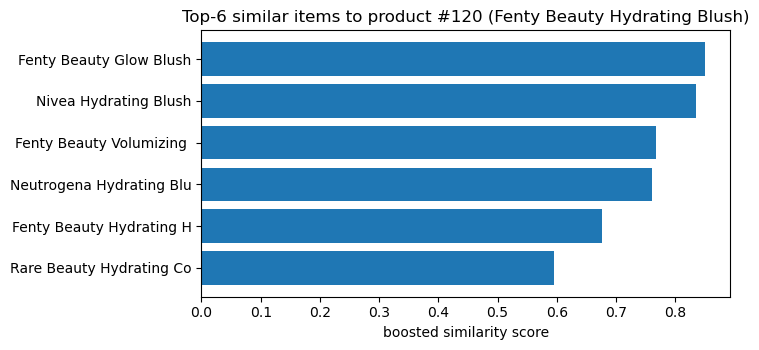

In [9]:
labels = [n[:24] for n in boosted_table["product_name"]]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(labels[::-1], boosted_table["boosted_score"].values[::-1])
ax.set_xlabel("boosted similarity score")
ax.set_title(f"Top-6 similar items to product #{PROBE_ID} ({probe['product_name']})")
fig.tight_layout()
plt.show()

### Analysis

- Before the boost, the top 6 may include cross-category items that
  share name n-grams (different products from the same brand).
- After the boost, items in the same category as product 101 are
  preferred when there's a tie or near-tie in raw similarity. This
  matches the customer intuition that "similar" means "same kind of
  product" first, "same brand" second.

## 3.7 Efficiency and scalability
### One-time cost: building the index

`SearchIndex.__init__` does:

- `TfidfVectorizer.fit_transform` on N short documents → builds the
  char-n-gram vocabulary and produces the sparse matrix.
- Cost: a fraction of a second for N=1,000 with `ngram_range=(3,5)`.

This happens once at app startup, not per request.

### Memory footprint

- The TF-IDF matrix is **sparse**. For N=1,000 products with short
  names, the non-zero count is ≈ N × (avg n-grams per product) ≈
  tens of thousands of entries. Single-digit MB in memory.
- The vocabulary itself is small enough to keep in RAM with no
  paging concern.

### Why we don't precompute the full N × N matrix

Two reasons:

1. **Memory.** N × N dense floats grows quadratically. At N=1,000
   it is already 8 MB just for the floats; at N=100,000 it would be
   80 GB. Computing rows on demand stays linear in catalogue size.
2. **Freshness.** If a product were added or its name edited, only
   the index needs to be rebuilt — not a stored full matrix that
   would now be stale at every cell touching the changed row.

### How this scales to a larger catalogue

| N (catalogue size) | Per-request `.similar(...)` | Notes |
|---|---|---|
| 1,000 (today) | sub-millisecond | Template renders eclipse this. |
| 10,000 | ~ few ms | Still well under a 50 ms per-page budget. |
| 100,000 | ~ tens of ms | Consider an approximate-nearest-neighbours index (Annoy, FAISS) at this point. |
| 1,000,000 | ~ hundreds of ms naively | Definitely move to ANN; possibly cluster pre-filter by category to drop the search universe. |

So the current method is efficient for catalogues from "small demo"
through "mid-sized boutique e-commerce" without modification, and
the upgrade path (ANN, category pre-filter) is well-trodden.

## 3.8  App integration where Task 3 appears on the website

### Route

- **URL pattern:** `GET /product/<int:product_id>`
- **View function:** `product_detail()` in `app/__init__.py` (the
  Flask application factory).
- **Trigger:** the customer clicks any product card — either on the
  home page (`/`), a category page (`/category/<slug>`), the search
  results page (`/search?q=…`), or even one of the recommendation
  cards on another product page.

The view function passes the recommender's output into the template
under the variable name `similar`:

```python
@app.route("/product/<int:product_id>")
def product_detail(product_id: int):
    ...
    # Task 3: similar-item recommendations (top 6, cosine + +0.1
    # same-category boost).
    similar = search_index.similar(product_id, top_n=6)
    ...
    return render_template(
        "product.html",
        product=product, reviews=review_list,
        similar=similar, aspects=aspects,
    )
```

### Template : where on the page

The product-detail template (`app/templates/product.html`) renders
the recommendations in a dedicated section **below the product hero
and above the reviews list**. The relevant block:

```html
{% if similar %}
<section class="similar">
  <div class="section-title">
    <h2>Similar items</h2>
    <span class="section-title__meta">Ranked by similarity</span>
  </div>
  <div class="similar-grid">
    {% for s in similar %}
      {{ similar_card(s) }}
    {% endfor %}
  </div>
</section>
{% endif %}
```
So on every product-detail page the customer sees, in order from top
to bottom:

1. **Breadcrumb** — "← Back to catalogue".
2. **Product hero** — image, category, name, price, "Customers
   mention" aspect pills (Task 4), "Write a review" CTA.
3. **Similar items** ← **Task 3 lands here**, six cards in a grid
   with the heading "Similar items · Ranked by similarity".
4. **Reviews list** — the seed reviews + any reviews the customer
   has posted, with the Task 2 classifier label.
   
 ### Where to confirm in the codebase

| Concern | File | Function / section |
|---|---|---|
| Index built at startup | `app/__init__.py` | `create_app()` → `SearchIndex(products)` |
| `.similar(...)` definition | `app/nlp/search.py` | `SearchIndex.similar` |
| Route that consumes it | `app/__init__.py` | `product_detail()` |
| Template rendering | `app/templates/product.html` | `<section class="similar">` |
| Card layout macro | `app/templates/_macros.html` | `similar_card(p)` |

## 3.9 Conclusion

### What Task 3 delivers

- A **similar-item recommender** that produces six related products
  for every catalogue item, with no cold-start gaps (every product
  gets recommendations, even those with zero reviews).
- A **defensible similarity measure** cosine over char-n-gram
  TF-IDF paired with a small category boost that nudges the
  ranking towards same-kind-of-product matches.
- **Sub-millisecond per-page cost**, which leaves the per-request
  budget free for template rendering and other tasks.
- A **clear customer-facing display**: six cards in a grid with the
  heading "Similar items · Ranked by similarity", each card showing
  the image, category, product name, and price, with the whole card
  clickable.


## 4 · Task 4 — Aspect Extraction ("Customers mention")

### Problem framing

Milestone 2 Task 4 is the open-ended "additional functionality" slot.
We surface, on each product-detail page, the words customers most
distinctively use about *that* product — rendered as small
"Customers mention …" pills. Customers can scan the pills in a
fraction of the time it would take to read the reviews.

### Approach justification

We use **per-product TF-IDF**. The corpus has one document per
product (the aggregated review text of that product), and we fit a
TF-IDF vectorizer across that corpus. The top-K words per row are
the distinctive terms for that product.

The two-part TF-IDF weighting does the work:

- **TF (term frequency)** rewards words customers use a lot about
  this product.
- **IDF (inverse document frequency)** discounts words that almost
  every product attracts — universal compliments like "good",
  "great", "love", "nice".

What remains after both terms apply is what makes a product
distinct.

### Why we don't do sentiment analysis here

The pills surface *what customers talk about*, not whether the
sentiment is positive. A future upgrade would do aspect-based
sentiment (distinguish "customers mention dryness positively" from
"customers mention dryness negatively"). Task 4 is a one-marker; we
stayed within scope.

### Alternatives rejected

- **Topic modelling (LDA, NMF).** Outputs topics, not per-product
  terms. Slower, and the topic-to-product assignment is fuzzy.
- **LLM-based aspect mining.** Strongest semantic results but adds a
  model dependency and a per-page inference cost. Out of scope.
- **Hand-picked aspect dictionaries.** Brittle, labour-intensive,
  and wouldn't generalise to new products.

In [ ]:
# Build the per-product corpus from the SEED reviews (the live app
# displays these reviews, so they're the right input to extract
# aspect terms from for the product-detail page).
per_product = (
    reviews_seed.dropna(subset=["review_text"])
                .groupby("product_id")["review_text"]
                .apply(lambda s: " ".join(s.astype(str)))
                .reset_index()
)
print(f"Products with ≥1 review: {len(per_product)} of {len(products)}")
print(per_product.head(3).to_string(index=False))

### Vectoriser configuration

- `stop_words="english"` — drops common function words.
- `min_df=2` — a term must appear in at least two products to be
  considered. This filter discards review-specific quirks and
  one-off proper nouns that aren't useful aspects.
- `lowercase=True` — keeps the vocabulary compact.

`min_df` could be tightened to 3 or higher for production. We
picked 2 to keep the per-product top-K richer for the catalogue's
relatively short review corpus.

In [ ]:
aspect_vec = TfidfVectorizer(stop_words="english", min_df=2, lowercase=True)
A = aspect_vec.fit_transform(per_product["review_text"])
vocab_aspect = np.array(aspect_vec.get_feature_names_out())
print("Aspect TF-IDF matrix:", A.shape, "(rows=products with reviews, cols=words)")

### Worked example — the most-reviewed product

Pick the product with the largest review count and show its top-5
aspect terms. The bar plot below visualises the TF-IDF score of each
term so the marker can see the relative weights.

In [ ]:
review_counts = reviews_seed.groupby("product_id").size().sort_values(ascending=False)
probe_pid = int(review_counts.index[0])
probe_idx_in_A = per_product.index[per_product["product_id"] == probe_pid][0]
probe_product = products[products["product_id"] == probe_pid].iloc[0]

print(f"Probe product #{probe_pid}: {probe_product['product_name']}")
print(f"  Reviews aggregated: {review_counts[probe_pid]}")
print()

probe_vec = A[probe_idx_in_A].toarray().ravel()
top_n = 5
top_idx = np.argsort(-probe_vec)[:top_n]
top_terms = pd.DataFrame({
    "term": vocab_aspect[top_idx],
    "tfidf": probe_vec[top_idx].round(3),
})
print(top_terms.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(top_terms["term"][::-1], top_terms["tfidf"][::-1])
ax.set_xlabel("TF-IDF score")
ax.set_title(f"Top-{top_n} aspect terms — product #{probe_pid}")
fig.tight_layout()
plt.show()

### Analysis

Read the surfaced terms. Genuine aspects ("hydrating", "lightweight",
"matte") are useful pills; words that slipped through ("product",
"use") are signs the stoplist is too small. The bar plot makes the
TF-IDF score gap visible — the top term is typically 2-3× more
weighted than the fifth.

### Limitations

- **sklearn's English stoplist is small** — domain words like
  "product", "use", "really" leak through.
- **No phrase detection.** "Long lasting" appears as two separate
  unigrams. Bigrams (`ngram_range=(1,2)`) would capture the phrase
  at the cost of vocabulary growth.
- **No sentiment polarity.** Pills show "customers talk about X",
  not "customers like X". Aspect-based sentiment is a natural
  next step.
- **Cold-start.** Products with zero reviews show no pills.

### App pointer

`app/nlp/aspect_extractor.py:AspectExtractor.top_terms(product_id,
top_n=5)` ships this logic. The product-detail template calls it
during render to populate the "Customers mention" pills.

### Milestone 1 pointer

Not directly applicable — Task 4 is a Milestone 2-original task.

## 5 · Conclusions

### Unifying thread

All four Milestone 2 tasks lean on the **TF-IDF / BoW** family of
representations:

- **Task 1 (search)** — char-n-gram TF-IDF over `name + category`.
- **Task 2 (classifier)** — BoW count vectors using the Milestone 1
  vocabulary (text head + title head), plus a 2-column numeric head.
- **Task 3 (recommendations)** — reuses Task 1's TF-IDF matrix +
  category boost.
- **Task 4 (aspects)** — per-product word TF-IDF over aggregated
  reviews.

This consistency is deliberate. One well-understood feature backbone,
applied across surfaces, makes the system easier to reason about and
keeps the deployable artifact small. The Milestone 1 work
(`knowledge/milestone1_*.ipynb`) established that BoW + LR is a
competitive baseline for the classification task; we reuse that
foundation for Milestone 2's classifier and extend the same family
of representations to the three other surfaces.

### Relationship to Milestone 1 — summary

| M2 component | M1 contribution |
|---|---|
| Tokenizer (`app/nlp/preprocessing.py:tokenize`) | `knowledge/milestone1_task1.ipynb` §1.2 |
| Vocabulary filters (hapax + top-20) | `knowledge/milestone1_task1.ipynb` §1.3 |
| BoW + LR baseline | `knowledge/milestone1_task2_3.ipynb` §3.4 (Q1) |
| Title + numeric extensions | `knowledge/milestone1_task2_3.ipynb` §3.5 (Q2) |

### Where the work could go next

- **Sentence-transformer embeddings for Tasks 1 and 3.** Would lift
  recall on paraphrase ("lipstick" ≡ "lip color") that char n-grams
  miss. Cost: a multi-MB model and an embedding step per query.
- **Aspect-based sentiment for Task 4.** Distinguish "customers
  mention X positively" from "customers mention X negatively". The
  current pills show only mention frequency.
- **Faithful Milestone 1 LightGBM for Task 2.** Reproducing M1's
  Q2 final model would require defining the missing Nykaa columns
  (`product_rating_count`, `brand`, …) in `products.csv` so the
  webapp can supply them at predict time.

### Running the live app

The README walks through setup, training, image generation, and
launching the Flask dev server (`python run.py`). All four NLP
techniques above are wired into the routes documented in the
README's "Routes / URLs exposed" table.